In [1]:
import torch
import torch.nn as nn
x = torch.rand(5, 3)
print(x)

tensor([[0.6456, 0.1355, 0.2118],
        [0.0342, 0.3250, 0.0596],
        [0.5480, 0.2408, 0.6526],
        [0.2793, 0.9594, 0.6567],
        [0.9803, 0.7138, 0.3188]])


In [2]:
print(torch.cuda.is_available())  
print(torch.cuda.get_device_name(0))
device = torch.device("cuda")
x = torch.randn(1, 3, dtype=float).to(device)
y = torch.randn(3, 1, dtype=float, device=device)
print(x.shape) 
print(x.dtype)
print(x)
print(y.shape) 
print(y.dtype)
print(y)

True
Tesla T4
torch.Size([1, 3])
torch.float64
tensor([[ 0.5215, -1.2058,  1.6381]], device='cuda:0', dtype=torch.float64)
torch.Size([3, 1])
torch.float64
tensor([[0.1540],
        [0.2176],
        [0.6648]], device='cuda:0', dtype=torch.float64)


In [3]:
a = torch.randn(3, 3).to(device)
print(a.dtype)  # should be float32

# Explicit cast
b = a.to(torch.float16)
print(b.dtype)  # float16 - this is what LLMs run in
print(torch.cuda.memory_allocated() / 1024**2, "MB")

torch.float32
torch.float16
0.001953125 MB


In [4]:
def multiply(a, b):
    return a @ b

print(multiply(x, y))

tensor([[0.9069]], device='cuda:0', dtype=torch.float64)


In [5]:
x = torch.randn(4, device='cuda')
y = torch.randn(4, device='cuda')
print(multiply(x, y))        # dot product - should be scalar
print(multiply(x, y).shape)  # what shape is it?

A = torch.randn(3, 4, device='cuda')
print(multiply(A, x))        # matrix-vector - should be shape (3,)
print(multiply(A, x).shape)

tensor(1.1196, device='cuda:0')
torch.Size([])
tensor([-0.4854, -0.5743, -0.5042], device='cuda:0')
torch.Size([3])


In [6]:
x = torch.tensor(4.0, requires_grad=True)
y = 3*x**2 + 2*x + 1

# what pytorch recorded - the last operation
print(y.grad_fn)

# one step back
print(y.grad_fn.next_functions)

# two steps back
print(y.grad_fn.next_functions[0][0].next_functions)

# three steps back
print(y.grad_fn.next_functions[0][0].next_functions[0][0].next_functions)

((<AddBackward0 object at 0x787454b00fa0>, 0), (None, 0))
((<MulBackward0 object at 0x787327344fd0>, 0), (<MulBackward0 object at 0x787454b00d30>, 0))
((<PowBackward0 object at 0x787454b00fa0>, 0), (None, 0))


In [7]:
y = x * x
print(y.grad_fn.next_functions)
# Output: ((<AccumulateGrad object at ...>, 0), (<AccumulateGrad object at ...>, 0))

((<AccumulateGrad object at 0x787454b02b30>, 0), (<AccumulateGrad object at 0x787454b02b30>, 0))


In [8]:
X = torch.randn(100, 1, device='cuda')
y = 2 * X + 3 + 0.1 * torch.randn(100, 1, device='cuda')

slope_weight = torch.randn(1, device="cuda", requires_grad=True)
bias_weight = torch.randn(1, device="cuda", requires_grad=True)

for step in range(100):
    
    prediction_values = slope_weight * X + bias_weight
    mse = ((prediction_values - y)**2).mean()
    if mse.item() < 0.1:
        print(f"converged at step {step}")
        break
    mse.backward()
    # print(mse)
    learning_rate = 0.3
    with torch.no_grad():
        w1 = (slope_weight.grad)
        w2 = (bias_weight.grad)
        slope_weight -= learning_rate*w1
        bias_weight -= learning_rate*w2
        slope_weight.grad.zero_()
        bias_weight.grad.zero_()
    # print(w1)
    # print(w2)
print(mse)
print(slope_weight)
print(bias_weight)

converged at step 3
tensor(0.0453, device='cuda:0', grad_fn=<MeanBackward0>)
tensor([1.9808], device='cuda:0', requires_grad=True)
tensor([2.8055], device='cuda:0', requires_grad=True)


In [ ]:
X = torch.randn(100, 1, device='cuda')
y = 2 * X + 3 + 0.1 * torch.randn(100, 1, device='cuda')
linear_model = nn.Linear(1, 1, device="cuda")
learning_rate = 0.3
optimizer = torch.optim.SGD(params=linear_model.parameters(), lr=learning_rate)
for step in range(1000):
    loss = ((linear_model(X) - y)**2).mean()
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

print(f"Learned Slope (Weight): {linear_model.weight.item():.4f}")
print(f"Learned Intercept (Bias): {linear_model.bias.item():.4f}")

test_x = torch.tensor([[10.0]], device="cuda")
with torch.no_grad():
    prediction = linear_model(test_x)
    print(f"Prediction for x=10: {prediction.item():.4f}")

Learned Slope (Weight): 1.9841
Learned Intercept (Bias): 2.9954
Prediction for x=10: 22.8362


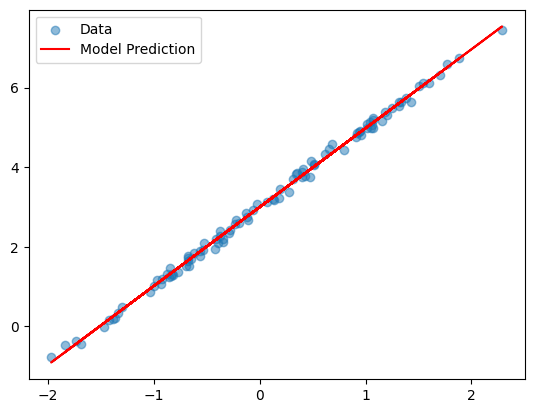

In [10]:
import matplotlib.pyplot as plt

# 1. Move to CPU and convert to NumPy
# .detach() is like saying "cut the umbilical cord to the graph"
X_cpu = X.cpu().numpy()
y_cpu = y.cpu().numpy()

with torch.no_grad():
    predictions_cpu = linear_model(X).cpu().numpy()

# 2. Plot the original "Noisy" dots
plt.scatter(X_cpu, y_cpu, label="Data", alpha=0.5)

# 3. Plot the "Learned" line
plt.plot(X_cpu, predictions_cpu, color='red', label="Model Prediction")
plt.legend()
plt.show()

In [ ]:
import numpy as np

A = np.array([[1, 2],
              [3, 4]])

x1 = np.array([10, 20])          # shape (2,)
x2 = np.array([[10], [20]])      # shape (2,1)

out1 = A @ x1
out2 = A @ x2

print(out1, out1.shape)
print(out2, out2.shape)

[ 50 110] (2,)
[[ 50]
 [110]] (2, 1)


In [12]:
x1 = np.array([50, 110])       # shape (2,)
x2 = np.array([[50], [110]])   # shape (2,1)

print(x1[0])     # what do you get?
print(x2[0])     # what do you get?

50
[50]


In [13]:
tensorX = torch.randn(3, 2)
tensorY = torch.randn(2, 5)

vectorX = torch.randn(3)
vectorY = torch.randn(3)

batchX = torch.randn(6, 3, 2)
batchY = torch.randn(6, 2, 5)

queryM = torch.randn(5, 3, 5)
keyM = torch.randn(5, 3, 5)
#dot product
torch.einsum('i, i->', vectorX, vectorY)

#matrix multiply
torch.einsum('ij,jk->ik', tensorX, tensorY)

#batch matrix multiply
torch.einsum('bij, bjk -> bik', batchX, batchY)

#outer product
torch.einsum('i, j->ij', vectorX, vectorY)

#attention scores
torch.einsum('bij, bkj -> bik', queryM, keyM)

tensor([[[ 2.9593, -2.3281,  3.8378],
         [-2.9620,  0.4416, -1.1844],
         [-3.3982, -1.2220,  0.2237]],

        [[-0.2884,  1.8963, -1.0997],
         [-1.6668, -2.1522, -0.9319],
         [-1.0115, -2.5268, -1.1729]],

        [[-0.2800, -1.1239, -0.1684],
         [-4.4889,  0.0517, -0.0505],
         [-1.6577,  1.0723, -1.0200]],

        [[-1.6299,  1.2202,  3.8435],
         [ 0.9360, -1.4593, -2.4636],
         [-3.3496, -6.8170, -2.4726]],

        [[ 3.3955,  1.7855,  0.7767],
         [-5.2294, -3.3280,  0.0720],
         [-1.5737, -2.5696, -2.1502]]])

In [14]:
randTensorX = torch.randn(3, 2)
randTensorY = torch.randn(3, 1)

print(randTensorX.shape[0])
# torch.utils.data.dataset()

class RandomDataSet(torch.utils.data.Dataset):
    def __init__(self, tensor1, tensor2):
        self.tensor1 = tensor1
        self.tensor2 = tensor2
    
    def __len__(self):
        return self.tensor1.shape[0]
    
    def __getitem__(self, index):
        return [self.tensor1[index], self.tensor2[index]]

dataSet = RandomDataSet(tensor1=randTensorX, tensor2=randTensorY)
dataLoader = torch.utils.data.DataLoader(dataSet, batch_size=2, num_workers=5, pin_memory=True)
for interation in iter(dataLoader):
    print(interation[0])
    print(interation[1])


    x = interation[0].to(device)
    y = interation[1].to(device)


3


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


tensor([[-1.3628, -2.5415],
        [ 0.1387, -0.4123]])
tensor([[0.5835],
        [1.5244]])
tensor([[0.4537, 1.3349]])
tensor([[0.1093]])


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B")
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B").to("cuda")



Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [60]:
n = 5
inputs = tokenizer("Hello, my name is", return_tensors="pt").to("cuda")

for i in range(n):
    outputs = model.forward(**inputs)
    next_token = outputs.logits[0, -1, :].argmax()
    inputs["input_ids"] = torch.cat((inputs["input_ids"], next_token.reshape(1,1)), dim=1)
    print(type(outputs.past_key_values))
    # print(len(outputs.past_key_values))
    # print(inputs["input_ids"])
    # inputs += (output)
# outputs = model.generate(**inputs, max_new_tokens=25)
print(tokenizer.decode(inputs["input_ids"][0]))
# print(tokenizer.decode(next_token_id=))
# !nvidia-smi

<class 'transformers.cache_utils.DynamicCache'>
<class 'transformers.cache_utils.DynamicCache'>
<class 'transformers.cache_utils.DynamicCache'>
<class 'transformers.cache_utils.DynamicCache'>
<class 'transformers.cache_utils.DynamicCache'>
Hello, my name is Johnh and I friend
